In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data
from torch.utils.data import Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import math
from models.unet import UNet
from utils import strided_ddim_sample, check_posterior_logic, verify_training_inputs, check_noise_correlation, visualise_loader, make_beta_schedule, periodic_sample_grids, ancestral_sample, plot_ancestral_samples, plot_sampling_norms
from diffusion.diffusion import DiffusionProcess
from models.mnistfe import MNISTFeatureExtractor
from models.position_embedding import SinusoidalPositionEmbeddings
from scipy.linalg import sqrtm
from sklearn.metrics.pairwise import polynomial_kernel
from scipy.spatial import distance

In [29]:
EPOCHS = 50
L = 1000
BATCH = 128

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

Device: mps


In [30]:
class MLP2D(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU()
        )
        self.net = nn.Sequential(
            nn.Linear(2 + hidden_dim, hidden_dim * 2),
            nn.GELU(),
            nn.Linear(hidden_dim * 2, hidden_dim * 2),
            nn.GELU(),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        x_input = torch.cat([x, t_emb], dim=-1)
        return self.net(x_input)

In [31]:
def generate_8_gaussians(n_samples, scale=2.0, std=0.1):
    centers = [
        (1, 0), (-1, 0), (0, 1), (0, -1),
        (1./np.sqrt(2), 1./np.sqrt(2)),
        (1./np.sqrt(2), -1./np.sqrt(2)),
        (-1./np.sqrt(2), 1./np.sqrt(2)),
        (-1./np.sqrt(2), -1./np.sqrt(2))
    ]
    centers = np.array(centers) * scale
    indices = np.random.randint(0, 8, n_samples)
    samples = centers[indices] + np.random.randn(n_samples, 2) * std
    return samples, centers

ground_truth_std = 0.1
train_samples, _ = generate_8_gaussians(10000, std=ground_truth_std)
train_tensor = torch.tensor(train_samples, dtype=torch.float32)
dataloader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_tensor), batch_size=256, shuffle=True
)

In [32]:
L_2d = 100

diff_2d = DiffusionProcess(L=L_2d, device=device) 
model_2d = MLP2D().to(device)
optimizer_2d = optim.Adam(model_2d.parameters(), lr=1e-3)
criterion = nn.MSELoss()

model_2d.train()
epochs = 300

for epoch in tqdm(range(epochs)):
    for batch in dataloader:
        x0 = batch[0].to(device)
        batch_size = x0.shape[0]
        t = diff_2d.sample_timesteps(batch_size)
        noise = torch.randn_like(x0)

        xt = diff_2d.q_sample(x0, t, noise)

        noise_pred = model_2d(xt, t)
        loss = criterion(noise_pred, noise)
        
        optimizer_2d.zero_grad()
        loss.backward()
        optimizer_2d.step()

100%|██████████| 300/300 [01:28<00:00,  3.38it/s]


In [33]:
model_2d.eval()
with torch.no_grad():
    xi = torch.randn(2000, 2, device=device)

    for i in reversed(range(diff_2d.L)):
        t_tensor = torch.full((2000,), i, device=device, dtype=torch.long)
        eps_hat = model_2d(xi, t_tensor)

        xi = diff_2d.p_sample_step(xi, t_tensor, eps_hat)

fake_samples = xi.cpu().numpy() 
real_samples, mode_centers = generate_8_gaussians(2000, std=ground_truth_std)

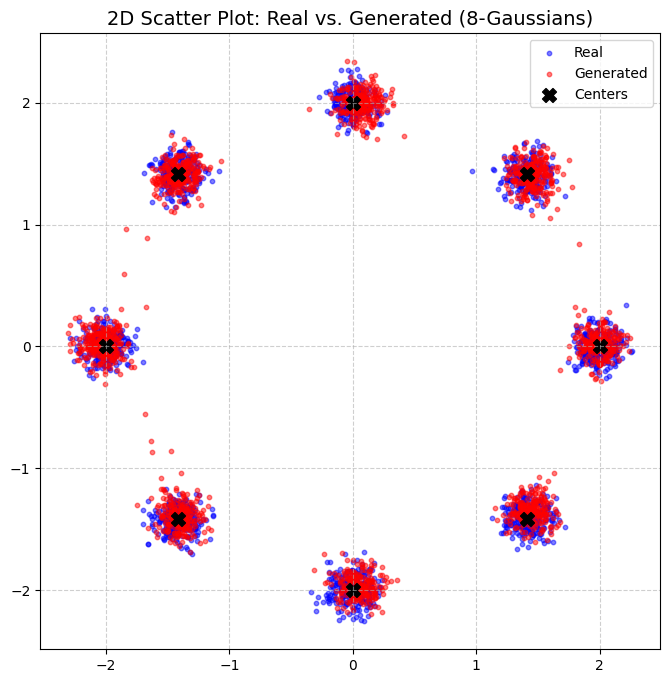

In [34]:
plt.figure(figsize=(8, 8))
plt.scatter(real_samples[:, 0], real_samples[:, 1], alpha=0.5, label='Real', s=10, c='blue')
plt.scatter(fake_samples[:, 0], fake_samples[:, 1], alpha=0.5, label='Generated', s=10, c='red')
plt.scatter(mode_centers[:, 0], mode_centers[:, 1], color='black', marker='X', s=100, label='Centers')

plt.title("2D Scatter Plot: Real vs. Generated (8-Gaussians)", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [35]:
def evaluate_coverage(fake_samples, centers, gt_std):
    dist_matrix = distance.cdist(fake_samples, centers)
    nearest_center_indices = np.argmin(dist_matrix, axis=1)
    min_distances = np.min(dist_matrix, axis=1)
    
    threshold = gt_std * 3
    valid_points_mask = min_distances < threshold
    valid_indices = nearest_center_indices[valid_points_mask]
    
    coverage_count = len(np.unique(valid_indices))
    hq_percentage = (np.sum(valid_points_mask) / len(fake_samples)) * 100
    
    print("====== QUANTITATIVE COVERAGE DIAGNOSTICS ======")
    print(f"Modes Covered:          {coverage_count}")
    print(f"High Quality Samples:   {hq_percentage:.2f}% (Points within 3 std of a mode)")
    print("-----------------------------------------------")
    
    for i in range(len(centers)):
        mode_points = fake_samples[(nearest_center_indices == i) & valid_points_mask]
        if len(mode_points) > 0:
            mode_mean = np.mean(mode_points, axis=0)
            mode_std = np.std(mode_points, axis=0)
            print(f"Mode {i+1} | Captured: {len(mode_points):4d} pts | Mean: [{mode_mean[0]:5.2f}, {mode_mean[1]:5.2f}] | Std: [{mode_std[0]:4.2f}, {mode_std[1]:4.2f}]")
        else:
            print(f"Mode {i+1} | DROPPED (Mode Collapse!)")

In [36]:
evaluate_coverage(fake_samples, mode_centers, ground_truth_std)

====== QUANTITATIVE COVERAGE DIAGNOSTICS ======
Modes Covered:          8
High Quality Samples:   97.35% (Points within 3 std of a mode)
-----------------------------------------------
Mode 1 | Captured:  239 pts | Mean: [ 1.99,  0.01] | Std: [0.09, 0.09]
Mode 2 | Captured:  291 pts | Mean: [-2.03,  0.02] | Std: [0.09, 0.10]
Mode 3 | Captured:  240 pts | Mean: [ 0.06,  2.00] | Std: [0.09, 0.09]
Mode 4 | Captured:  212 pts | Mean: [ 0.05, -1.97] | Std: [0.10, 0.09]
Mode 5 | Captured:  246 pts | Mean: [ 1.45,  1.41] | Std: [0.09, 0.10]
Mode 6 | Captured:  220 pts | Mean: [ 1.44, -1.35] | Std: [0.10, 0.09]
Mode 7 | Captured:  270 pts | Mean: [-1.41,  1.41] | Std: [0.09, 0.09]
Mode 8 | Captured:  229 pts | Mean: [-1.40, -1.40] | Std: [0.09, 0.10]
